## Daniel Peña Fonseca

Use of LLMs (ChatGPT) for this exercise:
- Common use: Used for most exercises for debugging and to do plots faster. 

- Exercise 2.1: LLM was used to corrrectly scale the mnist data (np.float32). Used to make the code cleaner for the Cifar-10 with the notation $[:, :, :, l]$, avoiding the use of multiple loops as I had before.
- Exercise 2.2: Although the MNIST model's architecture (models.Sequential()) was created using the statement indications, it was helpful for the rest of the steps (compile, checkpoint, history). I.e. it was used to familiarize with tensorflow library, since I did not know anything about this module before doing this exercise. 
- Exercise 2.3: It was not really used for the CIFAR part, since I searched the internet for an optimal architecture of the model (link included later).
- Exercise 2.4: Initially, the knn classifier was implemented by hand; and since it was really slow, an LLM was used to optimize it. After vectorizing the operations to make them quicker, the program was still slow; and finally, the library sklearn was used with the help of an LLM. Some parts of the original code have been left for comparison. Also useful for (knn.fit, knn.score) and for handling the descending order of the $k$ values using lambda.
- Exercise 2.5: Useful for Counter(k_nearest_labels).most_common and for generating the plots code faster. The same applied for Cifar10.
- Exercise 2.6: Since I had no experience with HOG, separating images in patches, creating a code book, it was extensively used for those matters; especially for answering plenty of questions regarding how does hog and the bag of visual words work. In these cases it was also helpful for determining what range of parameters would be interesting to study, since there were plenty of them. It was also helpful for turning code valid for the MNIST data set into code valid for CIFAR10 (handling color); especially with the idea of adding the variable is_color in some functions to handle color, avoiding the need of having two functions: one for MNIST and one for CIFAR. 

# Exercise 2

In [1]:
%pip install -q scikit-image scikit-learn tensorflow

Note: you may need to restart the kernel to use updated packages.


In [27]:
import numpy as np
import math
from matplotlib import pyplot as plt
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model
from tensorflow.keras import layers, models
from sklearn.neighbors import KNeighborsClassifier
import statistics
import copy
from collections import Counter

from skimage.feature import hog
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import normalize

# Exercise 2.1

For this exercise, we simply download the data. Note that for the MNIST images, we use min-max scaling, while z-score normalization is used for the Cifar10 images. Also note that when using z-score normalization for the Cifar10 data, we normalize per channel (per color); e.g. to normalize the red color of the pixels, we will use the mean and the standard deviation obtained from the red channel of the images, not using all the channels.

## MNIST

In [2]:
# Download MNIST data
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()


# min-max scaling. 
# float32 to avoid problems with the original types of the mnist data
# We use copy.deepcopy because otherwise, we could be scaling incorrectly if repeatedly running this jupyter cell
print(f'The shape of MNIST data is: {x_train_mnist.shape}')
x_train_mnist_scaled = copy.deepcopy(x_train_mnist.astype(np.float32) / 255.0)
x_test_mnist_scaled = copy.deepcopy(x_test_mnist.astype(np.float32) / 255.0)

print('After scaling MNIST:')
print(f' Minimum value: {x_train_mnist_scaled.min():.3f}')
print(f' Maximum value: {x_train_mnist_scaled.max():.3f}')

The shape of MNIST data is: (60000, 28, 28)
After scaling MNIST:
 Minimum value: 0.000
 Maximum value: 1.000


## CIFAR-10

In [3]:
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

In [4]:
# Cifar-10: z-score normalization

x_train_cifar = copy.deepcopy(x_train_cifar.astype(np.float32))
x_test_cifar = copy.deepcopy(x_test_cifar.astype(np.float32))

print(f' The shape of Cifar10 data is: {x_train_cifar.shape}')

x_train_cifar_scaled = np.empty_like(x_train_cifar)
x_test_cifar_scaled = np.empty_like(x_test_cifar)

for l in range(3):
    avg_train_color = np.mean(x_train_cifar[:,:,:,l])
    avg_test_color = np.mean(x_test_cifar[:,:,:,l])

    std_train_color = np.std(x_train_cifar[:,:,:,l])
    std_test_color = np.std(x_test_cifar[:,:,:,l])

    x_train_cifar_scaled[:, :, :, l] = ( (x_train_cifar[:, :, :, l] - avg_train_color)/std_train_color ).copy()
    x_test_cifar_scaled[:, :, :, l] = ( (x_test_cifar[:, :, :, l] - avg_test_color)/std_test_color ).copy()


 The shape of Cifar10 data is: (50000, 32, 32, 3)


In [5]:
print("After normalizing CIFAR-10:")
print(f' Training average: {np.mean(x_train_cifar_scaled):.3f}. Training std: {np.std(x_train_cifar_scaled):.3f}')
print(f' Test average: {np.mean(x_test_cifar_scaled):.3f}. Test std: {np.std(x_test_cifar_scaled):.3f}')

After normalizing CIFAR-10:
 Training average: 0.000. Training std: 1.000
 Test average: 0.000. Test std: 1.000


# Exercise 2.2

## MNIST CNN


Using the architecture described in the statement, we generate the architecture. Comments are located near each line to ensure that the steps indicated in the exercise's statement are included.
Since we are working with a classification problem, we will minimize the cross-entropy loss, and since we work with more than 2 classes, we use the categorical cross-entropy. We will split the data using 80/20: 80% of the training set is used for training, and 20% is used for validation, and we will keep the model that yields the highest validation accuracy. Finally, we set a batch size of 64. This value seems to work properly, since it is not too large nor too small.

Note: The metric that we use is the accuracy, since it is easier to interpret than the loss:
$$
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total predictions}}
$$
Here, we compute the probabilities that our model assigns for each sample. For each sample, the model answers 'what is the probability that this image belongs to class $C_i$ ($\forall i$)?'. To compute the loss of our model, we will only use the probability assigned for the correct class $p_{correct}$. Using sparse categorical crossentropy, we penalize differences between that probability and 1. E.g. the image is labeled as 1, and the model assigns a probability $p_{correct}$ to the image belonging to class 1; the smaller the probability $p_{correct}$, the higher the loss; the closer $p_{correct}$ to 1, the lower the loss.

When calculating the loss for the test, we are also using $\text{loss} = -\log(p_{correct})$. Given the shape of the logarithm, the closer $p_{correct}$ is to 0, the higher the loss, since the formula has a negative sign. If $p_{correct}=1$, $\log(p_{correct})=0 \Rightarrow$ no loss.

In [6]:

# Set up
mnist_model = models.Sequential([
    # First Convolutional Block: 1st & 2nd layer
    layers.Conv2D(32, (3,3), activation = 'relu', input_shape = (28,28,1)), # 1st layer - conv. layer with 16-64 filters (3x3), ReLU activation & batch normalization
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), # 2nd layer - Max pooling (2x2)

    # Second Convolutional Block: 2nd & 3rd layer
    layers.Conv2D(64, (3,3), activation = 'relu'), # 3rd layer - Convolution layer with 32-128 filters (3x3), ReLU activation, and batch normalization
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), # 4th layer - Max pooling (2x2)
    
    # Classifier Head: Flatten + 4th & 5th layer
    layers.Flatten(), 
    layers.Dense(128, activation='relu'), # 5th layer - Fully connected dense layer with 128 neurons, ReLU (dropout during training, dropout range (somewhere [0.2, 0.5])
    layers.Dropout(0.3),
    layers.Dense(10, activation = 'softmax') # Sixth layer - A layer with 10 neurons (=the number of classes) and a softmax activation function
    
])




# Training
mnist_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # sparse uses directly the numbers, like 3. categorical_crossentropy expects hotvectors: [0,0,0,1,0,...]
    metrics=['accuracy'] 
)


checkpoint = ModelCheckpoint(
    filepath="Assignment_2/best_mnist_model.keras", # we save the model in a file
    monitor="val_accuracy",
    save_best_only=True, # We keep the model at the epoch where we get maximum validation accuracy
    mode="max",
    verbose=1
)

history = mnist_model.fit(
    x_train_mnist_scaled,
    y_train_mnist,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint]
)


Epoch 1/20


/Users/daniel/anaconda3/envs/jupyter/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8952 - loss: 0.3564
Epoch 1: val_accuracy improved from None to 0.98450, saving model to best_mnist_model.keras

Epoch 1: finished saving model to best_mnist_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9474 - loss: 0.1743 - val_accuracy: 0.9845 - val_loss: 0.0473
Epoch 2/20
747/750 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9798 - loss: 0.0645
Epoch 2: val_accuracy did not improve from 0.98450
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9799 - loss: 0.0680 - val_accuracy: 0.9840 - val_loss: 0.0528
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9862 - loss: 0.0462
Epoch 3: val_accuracy improved from 0.98450 to 0.98525, saving model to best_mnist_model.keras

Epoch 3: finished saving model to best_mnist_model.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9852 - loss: 0.0492 - val_accuracy: 0.9852 - val_loss: 0.0551
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 

In [7]:
# Loading the model from a file where it is saved
best_mnist_model = load_model('Assignment_2/best_mnist_model.keras')

# Test loss and accuracy of the best model
test_loss, test_accuracy = best_mnist_model.evaluate(x_test_mnist_scaled, y_test_mnist)
print(f"Test loss: {test_loss:.4f}. Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9905 - loss: 0.0439
Test loss: 0.0439. Test accuracy: 0.9905


# Exercise 2.3

## CIFAR10 CNN

The same procedure as described in Exercise 2.2. is followed in this case. 

However, for this exercise, I searched the internet looking for a CNN structure that performs well over the Cifar10 dataset. Using this link, https://www.kaggle.com/code/faressayah/cifar-10-images-classification-using-cnns-88, the architecture for the CNN that is presented below was obtained. Since the results satisfied the requirements indicated in the exercise's statement, this structure was kept.

In [8]:
cifar_model = models.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3,3), padding = 'same', activation = 'relu', input_shape = (32,32,3)), 
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), padding = 'same', activation = 'relu'), 
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), 
    layers.Dropout(0.3),

    # Second Convolutional Block
    layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu'), 
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), padding = 'same', activation = 'relu'), 
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), 
    layers.Dropout(0.3),

    # Third Convolutional Block
    layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu'), 
    layers.BatchNormalization(),
    layers.Conv2D(128, (3,3), padding = 'same', activation = 'relu'), 
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)), 
    layers.Dropout(0.3),
    
    # Classifier Head
    layers.Flatten(), 
    layers.Dense(128, activation='relu'), 
    layers.Dropout(0.3),
    layers.Dense(10, activation = 'softmax') 
    
])




# Training
cifar_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'] 
)

checkpoint = ModelCheckpoint(
    filepath="Assignment_2/best_cifar_model.keras", # We save the model in a file
    monitor="val_accuracy",
    save_best_only=True, # We keep the model at the epoch where we get maximum validation accuracy
    mode="max",
    verbose=1
)

history = cifar_model.fit(
    x_train_cifar_scaled,
    y_train_cifar,
    epochs=10, # We reduce the number of epochs to reduce computational cost
    batch_size=64,
    validation_split=0.2,
    callbacks=[checkpoint]
)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.3297 - loss: 1.9121
Epoch 1: val_accuracy improved from None to 0.52400, saving model to best_cifar_model.keras

Epoch 1: finished saving model to best_cifar_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 64ms/step - accuracy: 0.4050 - loss: 1.6468 - val_accuracy: 0.5240 - val_loss: 1.3403
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.5336 - loss: 1.2982
Epoch 2: val_accuracy improved from 0.52400 to 0.63340, saving model to best_cifar_model.keras

Epoch 2: finished saving model to best_cifar_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.5544 - loss: 1.2440 - val_accuracy: 0.6334 - val_loss: 1.0671
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.6175 - loss: 1.0788
Epoch 3: val_accuracy improved from 0.63340 to 0.70040, saving model to best_cifar_model.keras

Epoch 3: finished saving model to best_cifar_model.keras
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - 

In [9]:

print(history.history['val_accuracy']) # Making sure that everything is working properly
best_cifar_model = load_model('Assignment_2/best_cifar_model.keras')

test_loss, test_accuracy = best_cifar_model.evaluate(x_test_cifar_scaled, y_test_cifar)
print(f"Test loss: {test_loss:.4f}. Test accuracy: {test_accuracy:.4f}")

[0.5239999890327454, 0.633400022983551, 0.7003999948501587, 0.7300000190734863, 0.7554000020027161, 0.7803000211715698, 0.7785000205039978, 0.7922999858856201, 0.7993000149726868, 0.8075000047683716]
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8002 - loss: 0.5775
Test loss: 0.5775. Test accuracy: 0.8002


# Exercise 2.4

For this exercise, we will use a kNN classifier to classify MNIST images. Applying the kNN classifier to a certain image in the, say, validation set, that we can call $A$ will consist on:
1. Compute the distance between every image in the training set and the image $A$. Different distance metrics can be used, but here, the euclidean distance will be used, applied to each pixel and summed over all the pixels in the image. The euclidean distance between image $A$ and an image $X_i$ from the training set is defined as follows:
$$
\text{distance}(A, X_i) = \sqrt{\sum_{j=1}^{d}(A_j - X_{i_{j}})^{2}}
$$
Where $j=1, ..., d$ where $d$ here is the number of pixels in the image.

2. Store the labels of the $k$ nearest (closest in distance) neighbors in a list.

3. The class that appears the most in that list, will be the class predicted by the model for the image $A$.

For each value of $k$ that we consider, we apply this procedure for every image in the validation set and we compute the validation accuracy. The value of $k$ for which the highest validation accuracy is obtained, will be the selected one.

The following link was useful for understanding a bit better how this model works and the metrics that we can use: https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/

## MNIST

In [10]:
# Training images: 80% of training set. Validation images: 20% of training set.
number_of_mnist_training_images = int(0.8*len(x_train_mnist_scaled))

mnist_training_images   = x_train_mnist_scaled[:number_of_mnist_training_images]
mnist_validation_images = x_train_mnist_scaled[number_of_mnist_training_images:]

mnist_training_labels   = y_train_mnist[:number_of_mnist_training_images]
mnist_validation_labels = y_train_mnist[number_of_mnist_training_images:]


mnist_validation_accuracy_k = []
for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # We fit the model over the training set
    knn.fit(mnist_training_images.reshape(len(mnist_training_images), -1), mnist_training_labels) # With reshape I flatten the images
    
    # Now we measure how accurate has been the model's classification
    accuracy = knn.score(mnist_validation_images.reshape(len(mnist_validation_images), -1), mnist_validation_labels)
    mnist_validation_accuracy_k.append((accuracy, k))
    print(f'Study of k={k} finished.')


Study of k=1 finished.
Study of k=2 finished.
Study of k=3 finished.
Study of k=4 finished.
Study of k=5 finished.
Study of k=6 finished.
Study of k=7 finished.
Study of k=8 finished.
Study of k=9 finished.
Study of k=10 finished.
Study of k=11 finished.
Study of k=12 finished.
Study of k=13 finished.
Study of k=14 finished.
Study of k=15 finished.
Study of k=16 finished.
Study of k=17 finished.
Study of k=18 finished.
Study of k=19 finished.
Study of k=20 finished.
Study of k=21 finished.
Study of k=22 finished.
Study of k=23 finished.
Study of k=24 finished.
Study of k=25 finished.


In [11]:
# I implemented the kNN classifier by hand, but since it was not optimized, it was extremely slow. In the next cell,
# the optimized version is presented. This piece of code is left here since it might be helpful for understanding how the 
# description given in the previous cell could be implemented without libraries.
"""
def mnist_euclidean_distance(image_1, image_2):
    "Calculates the distance between two images element-wise."
    distance = np.sqrt(np.sum((image_1 - image_2) ** 2))
    return distance

def mnist_knn_predict(training_images, training_labels, test_image, k):
    distances = []
    number_of_images = len(training_images)
    for i in range(number_of_images):
        dist = mnist_euclidean_distance(test_image, training_images[i])
        distances.append((dist, training_labels[i]))

    # We will only take into account the labels from the k nearest neighbors
    distances.sort(key=lambda x: x[0])
    k_nearest_labels = [label for _, label in distances [:k]] 

    return Counter(k_nearest_labels).most_common(1)[0][0]
"""
"""
# Counter(k_nearest_labels).most_common(1) returns [(most_present_label, number_of_times_it_appeared)]. Since we want most_present_label, we do:
# Counter(k_nearest_labels).most_common(1)[0][0]

# Using one k, I apply mnist_knn_predict to all the images of the validation set. 
# I compute how many predictions of the validation set were correct (number_of_correct_validation_predictions). 
# I compute the accuracy = number_of_correct_validation_predictions/len(validation_set)
# The k for which I get the maximum accuracy will be the chosen one.
"""
"""def mnist_knn_predict_vectorized(training_images, training_labels, test_image, k):
    # Compute all distances at once
    distances = np.sqrt(np.sum((training_images - test_image)**2, axis=(1,2)))  
    nearest_indices = np.argsort(distances)[:k]  # indices of k smallest distances
    k_nearest_labels = training_labels[nearest_indices]
    
    # Return most common label
    return Counter(k_nearest_labels).most_common(1)[0][0]"""



"""
# My implementation of kNN
validation_accuracy_k = []
for k in range(1, 26):
    number_of_correctly_classified_images = 0
    number_of_validation_images = len(mnist_validation_images)
    for index_validation_image in range(number_of_validation_images):

        prediction = mnist_knn_predict_vectorized(mnist_training_images, mnist_training_labels, mnist_validation_images[index_validation_image], k)
        real_value =  mnist_validation_labels[index_validation_image]

        if prediction == real_value:
            number_of_correctly_classified_images += 1
        
    accuracy = number_of_correctly_classified_images/number_of_validation_images
    validation_accuracy_k.append((accuracy, k))
    print(f'Study of k={k} finished.')

validation_accuracy_k.sort(key=lambda x: x[0], reverse=True)

print(f'For k={validation_accuracy_k[0][1]} we get the highest accuracy: {validation_accuracy_k[0][0]}')"""

"\n# My implementation of kNN\nvalidation_accuracy_k = []\nfor k in range(1, 26):\n    number_of_correctly_classified_images = 0\n    number_of_validation_images = len(mnist_validation_images)\n    for index_validation_image in range(number_of_validation_images):\n\n        prediction = mnist_knn_predict_vectorized(mnist_training_images, mnist_training_labels, mnist_validation_images[index_validation_image], k)\n        real_value =  mnist_validation_labels[index_validation_image]\n\n        if prediction == real_value:\n            number_of_correctly_classified_images += 1\n\n    accuracy = number_of_correctly_classified_images/number_of_validation_images\n    validation_accuracy_k.append((accuracy, k))\n    print(f'Study of k={k} finished.')\n\nvalidation_accuracy_k.sort(key=lambda x: x[0], reverse=True)\n\nprint(f'For k={validation_accuracy_k[0][1]} we get the highest accuracy: {validation_accuracy_k[0][0]}')"

In [12]:
# mnist_validation_accuracy_k is a list with tuples of this shape: (accuracy, k).
# we want to see which k yields the highest validation accuracy. Therefore, we sort in descending order using the first value (key=lambda x: x[0])

# Descending order of accuracy
mnist_validation_accuracy_k.sort(key=lambda x: x[0], reverse=True)

# Now that we have the list sorted, the first tuple of the list (i.e. mnist_validation_accuracy_k[0]) will be (highest accuracy, k)
mnist_best_k = mnist_validation_accuracy_k[0][1]
mnist_best_k_accuracy = mnist_validation_accuracy_k[0][0]

print(f'MNIST: For k={mnist_best_k} we get the highest validation accuracy: {mnist_best_k_accuracy:.3f}')

# Model for k = mnist_best_k
mnist_knn = KNeighborsClassifier(n_neighbors=mnist_best_k, metric='euclidean')
mnist_knn.fit(mnist_training_images.reshape(len(mnist_training_images), -1), mnist_training_labels)
mnist_test_k_accuracy = mnist_knn.score(x_test_mnist_scaled.reshape(len(x_test_mnist_scaled), -1), y_test_mnist)

# The variable mnist_knn contains the kNN model for the MNIST data, using the k for which the highest validation accuracy was obtained

print(f'For k={mnist_best_k} we get')
print(f'Test accuracy: {mnist_test_k_accuracy:.3f}')


MNIST: For k=3 we get the highest validation accuracy: 0.970
For k=3 we get
Test accuracy: 0.967


## CIFAR

The same procedure described for the MNIST kNN classifier is followed in this case.

In [13]:
"""
def cifar_knn_predict_vectorized(training_images, training_labels, test_image, k):
    # Compute all distances at once
    
    distances = np.sqrt(np.sum((training_images[:, :, :, l] - test_image[:, :, :, l])**2, axis=(1,2,3)))
    nearest_indices = np.argsort(distances)[:k]  # indices of k smallest distances
    k_nearest_labels = training_labels[nearest_indices]
    
    # Return most common label
    return Counter(k_nearest_labels).most_common(1)[0][0]
"""

# Training images: 80% of training set. Validation images: 20% of training set.
number_of_cifar_training_images = int(0.8*len(x_train_cifar_scaled))

cifar_training_images   = x_train_cifar_scaled[:number_of_cifar_training_images]
cifar_validation_images = x_train_cifar_scaled[number_of_cifar_training_images:]

cifar_training_labels   = y_train_cifar[:number_of_cifar_training_images]
cifar_validation_labels = y_train_cifar[number_of_cifar_training_images:]

cifar_validation_accuracy_k = []
for k in range(1, 26):
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(cifar_training_images.reshape(len(cifar_training_images), -1), cifar_training_labels.ravel()) # With reshape I flatten the images
    accuracy = knn.score(cifar_validation_images.reshape(len(cifar_validation_images), -1), cifar_validation_labels.ravel())
    cifar_validation_accuracy_k.append((accuracy, k))
    print(f'Study of k={k} finished.')



Study of k=1 finished.
Study of k=2 finished.
Study of k=3 finished.
Study of k=4 finished.
Study of k=5 finished.
Study of k=6 finished.
Study of k=7 finished.
Study of k=8 finished.
Study of k=9 finished.
Study of k=10 finished.
Study of k=11 finished.
Study of k=12 finished.
Study of k=13 finished.
Study of k=14 finished.
Study of k=15 finished.
Study of k=16 finished.
Study of k=17 finished.
Study of k=18 finished.
Study of k=19 finished.
Study of k=20 finished.
Study of k=21 finished.
Study of k=22 finished.
Study of k=23 finished.
Study of k=24 finished.
Study of k=25 finished.


In [14]:
# Same procedure as for the MNIST dataset
# Descending order of accuracy
cifar_validation_accuracy_k.sort(key=lambda x: x[0], reverse=True)

cifar_best_k = cifar_validation_accuracy_k[0][1]
cifar_best_k_accuracy = cifar_validation_accuracy_k[0][0]

print(f'CIFAR: For k={cifar_best_k} we get the highest validation accuracy: {cifar_best_k_accuracy:.3f}')

# Model for k = mnist_best_k
cifar_knn = KNeighborsClassifier(n_neighbors=cifar_best_k, metric='euclidean')
cifar_knn.fit(cifar_training_images.reshape(len(cifar_training_images), -1), cifar_training_labels.ravel())
cifar_test_k_accuracy = cifar_knn.score(x_test_cifar_scaled.reshape(len(x_test_cifar_scaled), -1), y_test_cifar.ravel())


print(f'For k={cifar_best_k} we get')
print(f'Test accuracy: {cifar_test_k_accuracy:.3f}')


CIFAR: For k=1 we get the highest validation accuracy: 0.337
For k=1 we get
Test accuracy: 0.341


## Exercise 2.5

For this exercise, we follow the same procedure described above. Although now that the model is trained, we only have to do the three steps described previously (and include the representation: step 4). If we have a test image $T$:

1. Compute the euclidean distance between every image in the training set and the image $T$. 

2. Store the labels of the $k$ nearest neighbors in a list. Now, we also store the $k$ nearest neighbors; i.e. the images.

3. The class that appears the most in that list, will be the class predicted by the model for the image $T$.

4. We present the image $T$ and its nearest neighbors. This representation will be helpful for understading why the model classified the image as it did.

The function mnist_knn_predict_vectorized_2 computes steps 1,2 and 3, returning the indices from the nearest images (nearest_indices), and the class predicted by the model for the image under study. The rest of the code in the following cell generates the images (step 4).

## MNIST

(10000, 28, 28)


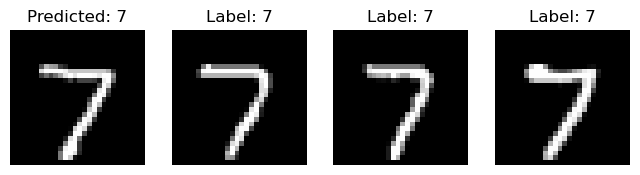

Figure shown


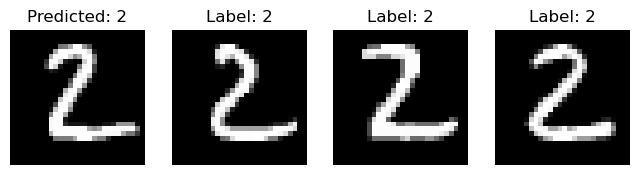

Figure shown


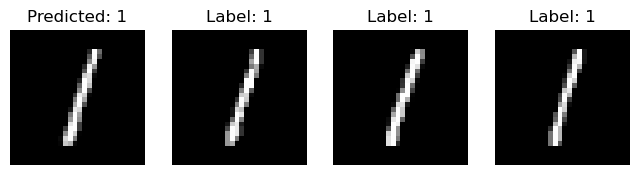

Figure shown


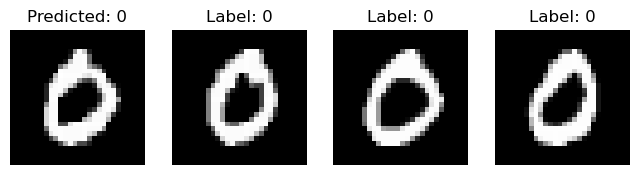

Figure shown


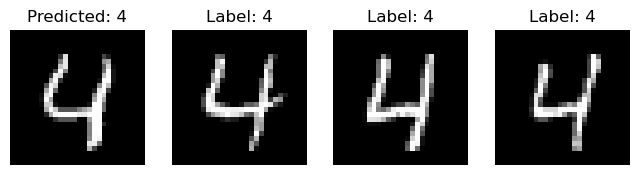

Figure shown


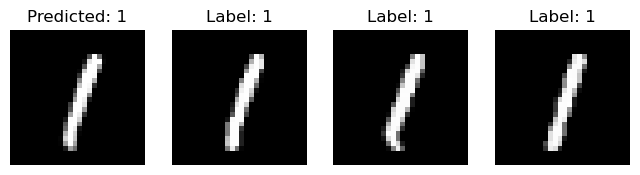

Figure shown


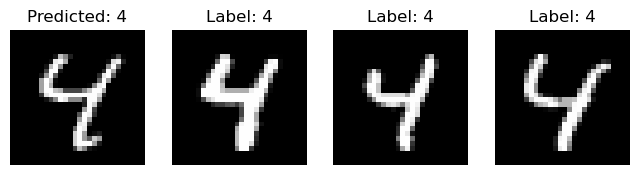

Figure shown


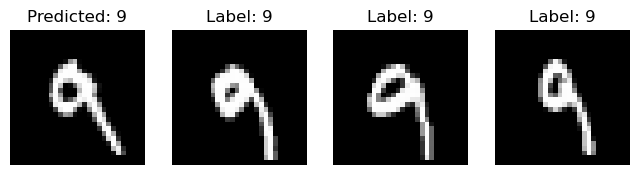

Figure shown


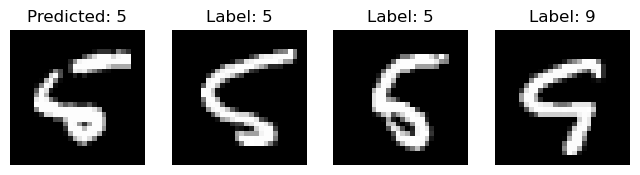

Figure shown


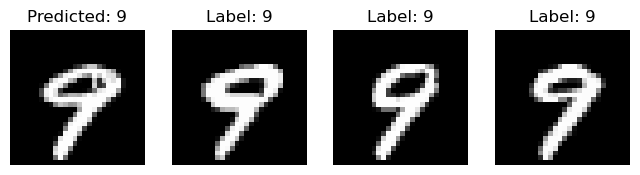

Figure shown


In [15]:
print(x_test_mnist.shape)

def mnist_knn_predict_vectorized_2(training_images, training_labels, test_image, k):
    # Compute all distances at once
    distances = np.sqrt(np.sum((training_images - test_image)**2, axis=(1,2)))  
    nearest_indices = np.argsort(distances)[:k]  # indices of k smallest distances
    k_nearest_labels = training_labels[nearest_indices]
    
    # Return most common label
    # if k_nearest_labels = [5,5,8,5,8], then Counter(k_neares_labels) creates a dictionary {5: 3, 8: 2}
    # Counter(k_nearest_labels) returns the most present (highest value) along with its key as a list with a tuple [(5,3)]
    # Counter(k_nearest_labels).most_common(1)[0] would be (5,3), and since we want the key (label), we use Counter(k_nearest_labels).most_common(1)[0][0]
    return nearest_indices, Counter(k_nearest_labels).most_common(1)[0][0]



number_of_test_images_presented = 10
for i in range(number_of_test_images_presented):

    nearest_indices, prediction = mnist_knn_predict_vectorized_2(mnist_training_images, mnist_training_labels, x_test_mnist_scaled[i], mnist_best_k)

    # Create figure: 1 test image + k neighbors
    plt.figure(figsize=(2 * (mnist_best_k + 1), 3))

    # On the left, the test image. On the right, the k nearest neighbors.

    # Plot test image
    number_of_rows = 1
    number_of_columns = mnist_best_k + 1
    plt.subplot(number_of_rows, number_of_columns, 1) # the last number is the plot index (column of the figure)
    plt.imshow(x_test_mnist_scaled[i], cmap="gray")
    plt.title(f"Predicted: {prediction}")
    plt.axis("off")

    # Plot nearest neighbors
    # j goes over the plot indices, idx goes over the indices from the nearest neighbors
    for j, idx in enumerate(nearest_indices):
        plt.subplot(number_of_rows, number_of_columns, j + 2)
        plt.imshow(mnist_training_images[idx], cmap="gray")
        plt.title(f"Label: {mnist_training_labels[idx]}")
        plt.axis("off")


    plt.show()
    print('Figure shown')


## CIFAR

The same procedure described above for the MNIST dataset is followed here. However, in this case, a definition was added to improve comprehension.
While MNIST data set studies numbers from 0 to 9, and therefore, the labels match these numbers; the cifar10 has a different situation. In Cifar10, label 0 corresponds to class 'airplane', label 1 corresponds to class 'automobile', etc. Since we are going to output the images next to their nearest neighbors, it is better if, instead of outputting the label number (0 to 9), we output the name of the class (airplane, automobile, ...).
For this, I defined the function cifar_number_to_class_name(prediction), where 'prediction' indicates the label number (from 0 to 9).

(10000, 32, 32, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7969961..2.0874546].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1796019..0.7899933].


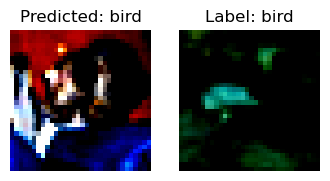

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0036852..1.9810143].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8939644..2.1267896].


Figure shown


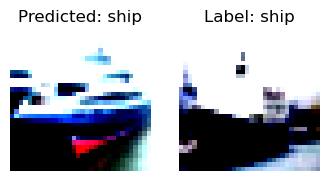

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9400886..2.05597].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0843536..1.5461336].


Figure shown


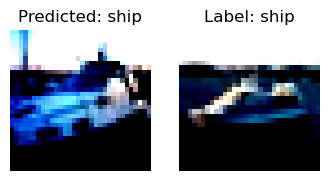

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4645133..1.7861296].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8191754..2.0858245].


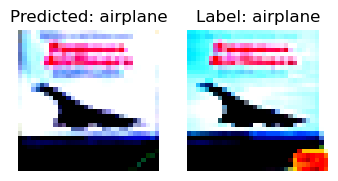

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8923911..1.5546592].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4165258..0.8523624].


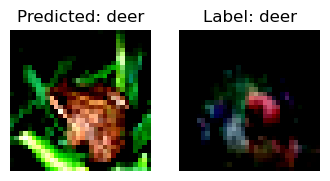

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9327272..1.3510377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3921834..1.0154771].


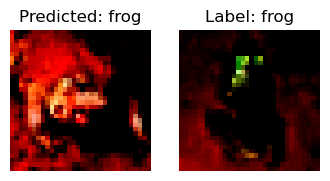

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.987786..2.1009433].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6581156..0.88662916].


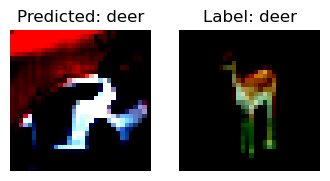

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6698029..2.1035998].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4653469..0.37612075].


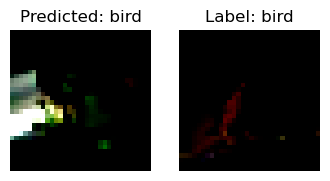

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7389835..2.0551639].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32779306..1.788971].


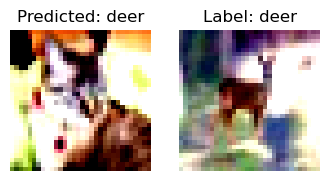

Figure shown


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6744022..2.040979].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.3859733..2.1267896].


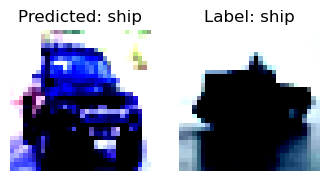

Figure shown


In [16]:

print(x_test_cifar.shape)


def cifar_knn_predict_vectorized_2(training_images, training_labels, test_image, k):
    # Compute all distances at once
    
    distances = np.sqrt(np.sum((training_images - test_image)**2, axis=(1,2,3)))
    nearest_indices = np.argsort(distances)[:k]  # indices of k smallest distances
    k_nearest_labels = training_labels[nearest_indices]
    
    # Return most common label
    return nearest_indices, Counter(k_nearest_labels).most_common(1)[0][0]


def cifar_number_to_class_name(prediction):
    association = {0: "airplane", 1: 'automobile', 2: 'bird', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'frog', 7: 'horse', 8: 'ship', 9: 'truck'}

    class_name = association[prediction]
    return class_name


number_of_test_images_presented = 10
for i in range(number_of_test_images_presented):

    nearest_indices, prediction = cifar_knn_predict_vectorized_2(cifar_training_images, cifar_training_labels.ravel(), x_test_cifar_scaled[i], cifar_best_k)

    # Create figure: 1 test image + k neighbors
    plt.figure(figsize=(2 * (cifar_best_k + 1), 3))

    # Plot test image
    number_of_rows = 1
    number_of_columns = cifar_best_k + 1
    plt.subplot(number_of_rows, number_of_columns, 1) # the last number is the index 
    plt.imshow(x_test_cifar_scaled[i])
    class_name = cifar_number_to_class_name(prediction)
    plt.title(f"Predicted: {class_name}")
    plt.axis("off")

    # Plot nearest neighbors
    for j, idx in enumerate(nearest_indices):
        plt.subplot(number_of_rows, number_of_columns, j + 2)
        plt.imshow(cifar_training_images[idx])
        class_name = cifar_number_to_class_name(cifar_training_labels[idx][0])
        plt.title(f"Label: {class_name}")
        plt.axis("off")

    plt.show()
    print('Figure shown')


# Discussion

Both when using the CNN model and the kNN algorithm, worst accuracies are obtained for the Cifar10 dataset. Since the MNIST dataset studies 2D images (numbers), where images of the same class have clear characteristics in common; the 3D images in Cifar10 are more complicated to classify. In the Cifar10, representations of the same object (same class) may have completely different shapes, given the perspective: An automobile seen from the front might seem more similar to a ship also seen from the front; than to a car seen by its side.

This perspective effect might also be the reason why the kNN performs noticeably worse than the CNN for the Cifar10 dataset. The kNN algorithm, using the euclidean distance, will suffer even more noticeably from a perspective swift in an image.

# Exercise 2.6

Seeking to improve the results, we will now use bag of visual words to consider more high-level features and patches over the images. However, the results obtained when using the bag of visual words have turned out being worse than those obtained when this approach was not followed.
Nevertheless, this could be given by a bad choice of parameters, although multiple combinations were tried.

## HOG
HOG stands for Histogram of Oriented Gradients, and it is a method that will be used to describe how edges are oriented in an image. Here follows an explanation for a black and white image:

1. For every pixel in the image, we compute the difference in brightness from left to right ($G_x$), and from bottom to top ($G_y$). This way, we obtain:
$$
\text{Magnitude}=\sqrt{G_x^2 + G_y^2}
$$
$$
\text{Angle}=\arctan{\frac{G_y}{G_x}}
$$
With the magnitude, we measure how strong is the change (how sharp is the edge); and with the angle, we measure the direction of the edge. With this model, we limit the 'allowed directions' to a finite number of orientations; i.e. if the model has 9 orientations: 0º, 20º, 40º, 60º, ..., 160º, and a certain pixel has an angle 42º, a weighted split is performed: most of its magnitude will be added to the 40º orientation, with just some addition to the 60º orientation.
Therefore, each pixel has a magnitude and an orientation associated. Although it could seem like the more the orientations, the better, since it could seem to be more descriptive, a high number of orientations may complicate the generalization.

2. Each pixel belongs to a cell (we can change the number of pixels per cell), and inside each cell we will measure how much magnitude we have for each orientation, using the magnitudes and orientations from each pixel in the cell. 

3. Each cell belongs to a block (we can also change te number of cells per block), and we will normalize the magnitudes using each block. 

4. Flattening into one list (feature vector) containing all the information.

Selecting the number of pixels per cell and the number of cells per block is not trivial, since low values may lead to excessive noise, while high values may prevent the detection of important features.

For an image with color (RGB), we will follow this approach for each of the colors (R, G, B): we compute the feature vector for each of the channels and then we concatenate, so we get a single feature vector for the image containing the feature vectors for each channel (each color).


The description just provided has some benefits and some downsides. On the one hand, it preserves the spatial information making it specially useful for datasets with simple characteristics, like the MNIST dataset. For example, for the MNIST dataset, the number 9 usually has a rounded shape on the top, and a straight line at the middle and bottom. Therefore, this process is optimal when the objects are centered, since the spatial information is preserved, but it is an approach highly sensitive to position.

However, this approach will unlikely be able to generalize when there are different perspectives. Example: A ship photographed by its side will have edges pointing in certain directions, but if the ship is moved to the left (say), and only half the ship is captured in the image, a HOG feature vector will not help in identifying that these structures actually correspond to the same type of object; i.e. same class.

Therefore, an alternative for these cases is the usage of dense patches combined with a bag of visual words (bovw). With this approach, we break an image into small patches, and we compute the HOG feature vector for each of these patches. All patches from all training images are then clustered together using Kmeans, which is unsupervised (ignores labels). Each cluster represents a 'visual word'; i.e. a recurring pattern found across the training dataset.

For example, studying the patches, we may have a visual word that indicates a very horizontal edge with high intensity, one that indicates a very vertical edge with high intensity, and one that indicates a very vertical edge with low intensity; those three visual words may represent the vocabulary. Each image will be characterized by how often each visual words appear in the image. In this case, if we had 4 patches, we could have $[2,1,1]$ if we had 2 patches with the first word, 1 with the second one and 1 with the last one. 

Since each training histogram (each histogram associated to a training image) is associated to its label, we can now use the kNN model to classify images previously unseen by the model.

When we want to classify a new image, we separate it into patches to generate the histogram using the vocabulary (visual words) learned from the training images. Even though the new image may not be well suited for being classified with the visual words defined by the training set, since it might have patches with unprecedented features, the model computes the distance between the 'characteristics' of the patch and all the visual words, and assigns it to the closest visual word. 
Once the histogram is created for the new image, we measure the distance between the new image's histogram and all the training histograms; we create a list with the labels of the k nearest neighbors (k nearest histograms), and we classify the image as the most common label in the list.

Selecting the number of clusters and the metric (distance) used, is also not trivial. If we use a low number of clusters (small vocabulary), noticeably different features will be clustered as the same, preventing proper classification; however, a large number of clusters would prevent generalization, since two patches closely related might be classified differently due to a small difference.

For the cluster generation; i.e. kmeans process, an interative process is followed. Say we want to use $n$ clusters:

1. First iteration: from the list containing all the patches descriptions, we randomly select $n$ patches as the clusters. The rest of the patches are assigned to their nearest cluster. The 'positions' of the clusters, are then recomputed as the average of the assigned patches; so these positions change.

2. Using the new positions from the clusters, we compute the 'distance' between each pair patch-cluster, and again assign each patch to its nearest cluster. In these iteration, most patches will probably switch clusters. The clusters' positions are recomputed as the average of the assigned patches.

3. The same process is repeated, but now fewer patches switch clusters, so the centers (clusters) move less than in the previous iterations.

4. We keep iterating until convergence. When the process converges, no patches switch clusters anymore, making the centers stable.

To make the process faster, although less accurate, we can use mini batches, which allow the computation of kmeans using, in each iteration, a subset of the training images.

After generating the codebook (build_codebook), kmeans can be used as follows:
- kmeans.cluster_centers_ : array of shape ($n$, descriptor size). It essentially returns 'where' the clusters are.
- kmeans.predict(new_patch) : it finds the nearest center to new_patch. I.e. it turns the new_patch characteristics into the closest visual word. Therefore, applied to multiple patches, we assign each patch to its closest visual word. Once this is done, we generate the histogram for the new image.



In [21]:

def extract_hog_features(images, is_color=False):
    features = []
    # features will be a list of sublists, each sublist representing an image
    for image in images:
        # Cifar10
        if is_color:
            color_hogs = []
            # Handling different colors
            for c in range(image.shape[2]):
                # Parameters described in the text cell
                h = hog(image[:, :, c], orientations=9,
                        pixels_per_cell=(8, 8), cells_per_block=(2, 2),
                        feature_vector=True) # Flattening (step 4)
                color_hogs.append(h)
            # We concatenate the colors to have one sublist per image
            features.append(np.concatenate(color_hogs))
        # MNIST
        else:
            h = hog(image, orientations=8,
                    pixels_per_cell=(4, 4), cells_per_block=(3, 3),
                    feature_vector=True)
            features.append(h)
    return np.array(features)





# Patch extraction
def extract_dense_patches(images, patch_size=16, stride=2, is_color=False):
    all_patches = []
    patches_per_image = []

    
    # If the batch size is x, there will be x*x pixels inside.
    # If ppc (side of pixels per cell) is batch_size/2: pixels per cell = (x/2)*(x/2)=x*x/4
    # So we will have 2x2 cells, which seems convenient in this case
    
    ppc = patch_size // 2  # 2x2 HOG cell grid

    for image in images:
        image_patches = []
        h, w = image.shape[:2] # height, width

        # We go over the windows. (x,y) mark where each window starts
        for y in range(0, h - patch_size + 1, stride):
            for x in range(0, w - patch_size + 1, stride):
                # CIFAR
                if is_color:
                    # patch contains the pixels in the patch
                    patch = image[y:y + patch_size, x:x + patch_size, :]
                    # We concatenate the different channels in description
                    desc = np.concatenate([
                        hog(patch[:, :, c],
                            orientations=8,
                            pixels_per_cell=(ppc, ppc),
                            cells_per_block=(1, 1),
                            feature_vector=True)
                        for c in range(patch.shape[2])
                    ])
                # MNIST
                else:
                    patch = image[y:y + patch_size, x:x + patch_size]
                    desc = hog(patch,
                               orientations=8,
                               pixels_per_cell=(ppc, ppc),
                               cells_per_block=(1, 1),
                               feature_vector=True)

                # Note that we do not store the positions (x,y) of the description
                # we just store the descriptions (lack of spatial structure)
                image_patches.append(desc)

        # patches_per_image saves the patch characteristics for each image, and will be used to compute the histogram
        patches_per_image.append(np.array(image_patches))
        # all_patches will include all the patch characteristics, that will be used to generate the patches
        all_patches.extend(image_patches)

    return np.array(all_patches), patches_per_image




# Codebook using kmeans
# We use a seed for the random initial state to guarantee the same results for every run (same choice of initial clusters)
def build_codebook(patches, n_clusters=512, random_state=42):
    print(f"  Building codebook: {n_clusters} visual words from {len(patches)} patches.")
    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=random_state, # same initial patches for the Kmeans iteration process
        batch_size=4096, # we use less patches per iteration, making it faster, although less accurate
        n_init=5, # we repeat the process 5 times, and keep the best result
        verbose=0
    )
    kmeans.fit(patches) # iterative process
    return kmeans



# bag of visual words histograms

def build_bovw_histograms(patches_per_image, codebook, n_clusters):
    histograms = [] # this will store the histograms for each image

    for image_patches in patches_per_image:
        # We turn each patch into its nearest visual word
        word_assignments = codebook.predict(image_patches)
        # We generate the histogram for the image using its visual words
        hist, _ = np.histogram(word_assignments, bins=np.arange(n_clusters + 1))
        histograms.append(hist)

    histograms = np.array(histograms, dtype=np.float32)
    histograms = normalize(histograms, norm='l2') # normalizing
    return histograms



# bag of visual words pipeline
def bovw_pipeline(
    x_train, y_train,
    x_val,   y_val,
    x_test,  y_test,
    patch_size=16,
    stride=2, # small stride -> more accurate but slower
    n_clusters=512,
    k_range=range(1, 16),
    is_color=False,
    dataset_name="Dataset",
    subsample_for_codebook=100_000
):
    print(f"\n{'='*60}")
    print(f"  {dataset_name}  |  patch={patch_size}  stride={stride}  vocab={n_clusters}")
    print(f"{'='*60}")

    print("  Extracting training patches ...")
    # train_patches_flat will be all_patches (not grouped by images). This will be used for kmeans
    # train_patches_per_img will have the patches for each image (grouped by images)
    train_patches_flat, train_patches_per_img = extract_dense_patches(
        x_train, patch_size=patch_size, stride=stride, is_color=is_color
    )
    print(f"  Patches per image: ~{len(train_patches_flat) // len(x_train)}")
    print(f"  Total patches: {len(train_patches_flat)},  dim: {train_patches_flat.shape[1]}")

    # if there are more than 100.000 patches, we use only 100.000 of them (randomly chosen) to create the codebook
    idx = np.random.choice(
        len(train_patches_flat),
        min(subsample_for_codebook, len(train_patches_flat)),
        replace=False # do not pick the same patch twice
    )
    # We build the codebook
    codebook = build_codebook(train_patches_flat[idx], n_clusters=n_clusters)

    print("  Building histograms ...")
    # training histograms
    train_hists = build_bovw_histograms(train_patches_per_img, codebook, n_clusters)

    # Since the kmeans has already been done, we no longer need all_patches (not grouped by images). Hence: _
    # We only need the patches per image so we can extract the patches and build the histograms for each image
    _, val_patches_per_img  = extract_dense_patches(x_val,  patch_size, stride, is_color)
    val_hists  = build_bovw_histograms(val_patches_per_img,  codebook, n_clusters)

    # Same procedure followed for validation is followed for testing
    _, test_patches_per_img = extract_dense_patches(x_test, patch_size, stride, is_color)
    test_hists = build_bovw_histograms(test_patches_per_img, codebook, n_clusters)

    # For the labels, we make sure that they are lists of elements and not lists of sublists where each subblist has one element
    y_train_r = y_train.ravel()
    y_val_r   = y_val.ravel()
    y_test_r  = y_test.ravel()

    val_results = []
    for k in k_range:
        # Apparently, for these cases (bag of visual words) a cosine metric is more appropriate
        knn = KNeighborsClassifier(n_neighbors=k, metric='cosine', n_jobs=-1)
        knn.fit(train_hists, y_train_r) # We assign the labels from the training images to the training histograms
        acc = knn.score(val_hists, y_val_r) # validation accuracy
        val_results.append((acc, k))
        print(f"    k={k:2d}  val accuracy = {acc:.4f}")

    # The tuple (accuracy, k) with the highest accuracy will be the selected one, since it will indicate the best k
    best_acc, best_k = max(val_results, key=lambda x: x[0])
    print(f"\n  Best k = {best_k}  (val accuracy = {best_acc:.4f})")

    # The model with the best k (highest validation accuracy) will be used to compute the test accuracy
    knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='cosine', n_jobs=-1)
    knn_best.fit(train_hists, y_train_r)
    test_acc = knn_best.score(test_hists, y_test_r)
    print(f"  Test accuracy = {test_acc:.4f}")

    return knn_best, codebook, train_hists, test_hists, best_k, test_acc


# Now we run it

# MNIST
mnist_knn_bovw, mnist_codebook, _, _, mnist_bovw_best_k, mnist_bovw_test_acc = bovw_pipeline(
    x_train = mnist_training_images,    y_train = mnist_training_labels,
    x_val   = mnist_validation_images,  y_val   = mnist_validation_labels,
    x_test  = x_test_mnist_scaled,      y_test  = y_test_mnist,
    patch_size = 16,
    stride     = 1,
    n_clusters = 1024,   # vocabulary size (number of visual words)
    k_range    = range(1, 16),
    is_color   = False,
    dataset_name = "MNIST",
    subsample_for_codebook = 100_000
)
print(f"\nMNIST BoVW  →  best k={mnist_bovw_best_k},  test accuracy={mnist_bovw_test_acc:.4f}")



# Cifar10
cifar_knn_bovw, cifar_codebook, _, _, cifar_bovw_best_k, cifar_bovw_test_acc = bovw_pipeline(
    x_train = cifar_training_images,    y_train = cifar_training_labels,
    x_val   = cifar_validation_images,  y_val   = cifar_validation_labels,
    x_test  = x_test_cifar_scaled,      y_test  = y_test_cifar,
    patch_size = 16,
    stride     = 2,      
    n_clusters = 1024,   
    k_range    = range(1, 16),
    is_color   = True,
    dataset_name = "CIFAR-10",
    subsample_for_codebook = 100_000
)
print(f"\nCIFAR-10 BoVW  →  best k={cifar_bovw_best_k},  test accuracy={cifar_bovw_test_acc:.4f}")


  MNIST  |  patch=16  stride=1  vocab=1024
  Extracting training patches ...
  Patches per image: ~169
  Total patches: 8112000,  dim: 32
  Building codebook: 1024 visual words from 100000 patches.
  Building histograms ...
    k= 1  val accuracy = 0.9455
    k= 2  val accuracy = 0.9402
    k= 3  val accuracy = 0.9523
    k= 4  val accuracy = 0.9501
    k= 5  val accuracy = 0.9520
    k= 6  val accuracy = 0.9521
    k= 7  val accuracy = 0.9523
    k= 8  val accuracy = 0.9515
    k= 9  val accuracy = 0.9503
    k=10  val accuracy = 0.9493
    k=11  val accuracy = 0.9491
    k=12  val accuracy = 0.9485
    k=13  val accuracy = 0.9480
    k=14  val accuracy = 0.9472
    k=15  val accuracy = 0.9463

  Best k = 3  (val accuracy = 0.9523)
  Test accuracy = 0.9457

MNIST BoVW  →  best k=3,  test accuracy=0.9457

  CIFAR-10  |  patch=16  stride=2  vocab=1024
  Extracting training patches ...
  Patches per image: ~81
  Total patches: 3240000,  dim: 96
  Building codebook: 1024 visual words fro

# Discussion

Although multiple combinations of parameters were tried: different values for the number of clusters, for the pixels per cell, the cells per block, the stride, etc. no combination yielded the results suggested in the statement of the exercise. For cifar10, higher accuracies were obtained when we used the bag of visual words than whithout it; however, this does not occur for the MNIST dataset. The reason might be that an appropriate combination of parameters was not studied, or that the model was simplified to improve efficiency: maybe, incrementing the number of patches considered for the codebook or the batch size when using mini batch kmeans, would return better results.

All in all, the bag-of-visual-words approach seems really interesting, allowing models to study multiple features, and making our classifier robust to position.